# Chronos zero-shot (consommation)

**Zero-shot** forecasts: two windows (24 h and 48 h), naive **week-ago** baseline, **P10–P90** band on Chronos samples.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd

from src.forecasting import (
    EVAL_WINDOW_24H,
    EVAL_WINDOW_48H,
    mean_absolute_percentage_error,
    per_horizon_percentage_error,
    plot_forecast_comparison,
    plot_horizon_errors,
    run_chronos_eval,
)

/home/mquero/Projects/personal/prism/services/ml-engine/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data


In [2]:
df = pd.read_csv("../data/processed/energy_consumption_realized_resampled.csv")
y_series = df["megawatts"]
df.head()

,timestamp,megawatts,day_of_week,hour_of_day,month,is_weekend,is_bank_holiday
0,2023-12-31 23:00:00+00:00,53531.00,6,23,12,1,0
1,2024-01-01 00:00:00+00:00,51589.25,0,0,1,0,1
2,2024-01-01 01:00:00+00:00,51294.75,0,1,1,0,1
3,2024-01-01 02:00:00+00:00,48886.50,0,2,1,0,1
4,2024-01-01 03:00:00+00:00,46812.25,0,3,1,0,1


## Experiences


=== 24 h — Chronos T5 Tiny ===
prediction_length=24, window=context_168h_horizon_24h


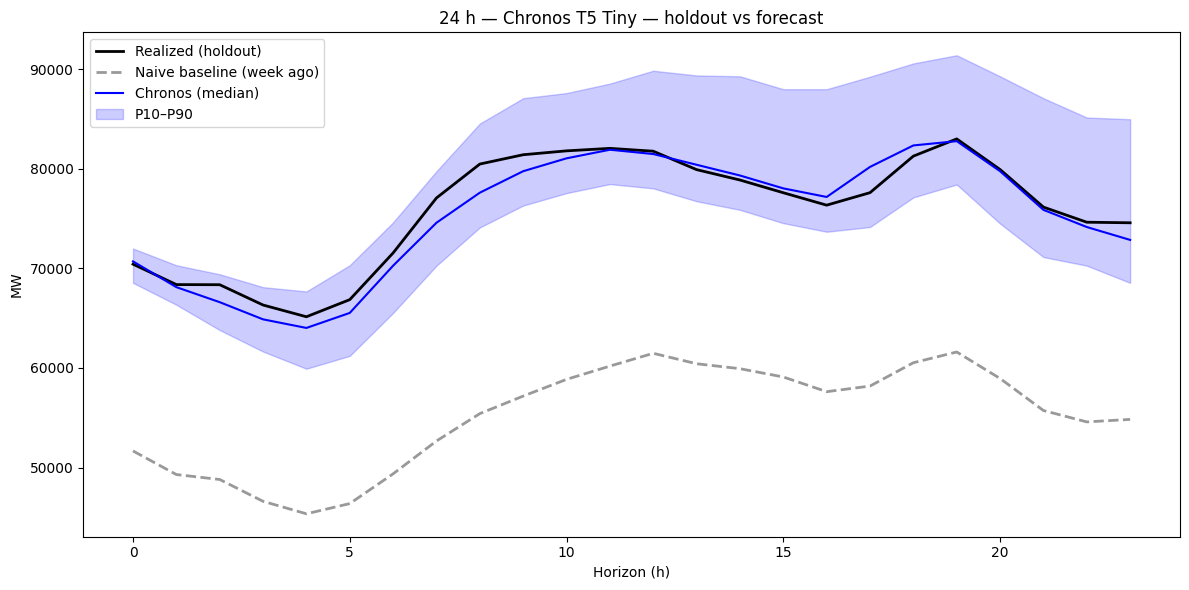

MAPE (Chronos median vs realized): 1.36%
MAPE (naive baseline vs realized): 27.35%
H+1: 0.40%
H+24: 2.31%


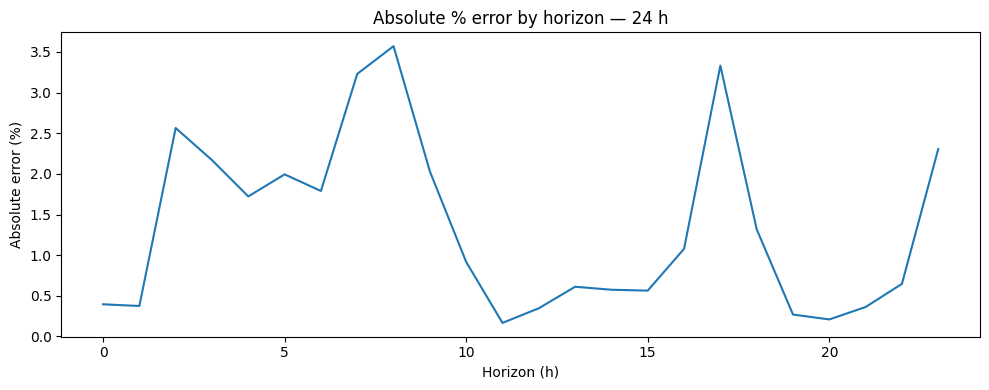


=== 48 h — Chronos T5 Base ===
prediction_length=48, window=context_336h_horizon_48h


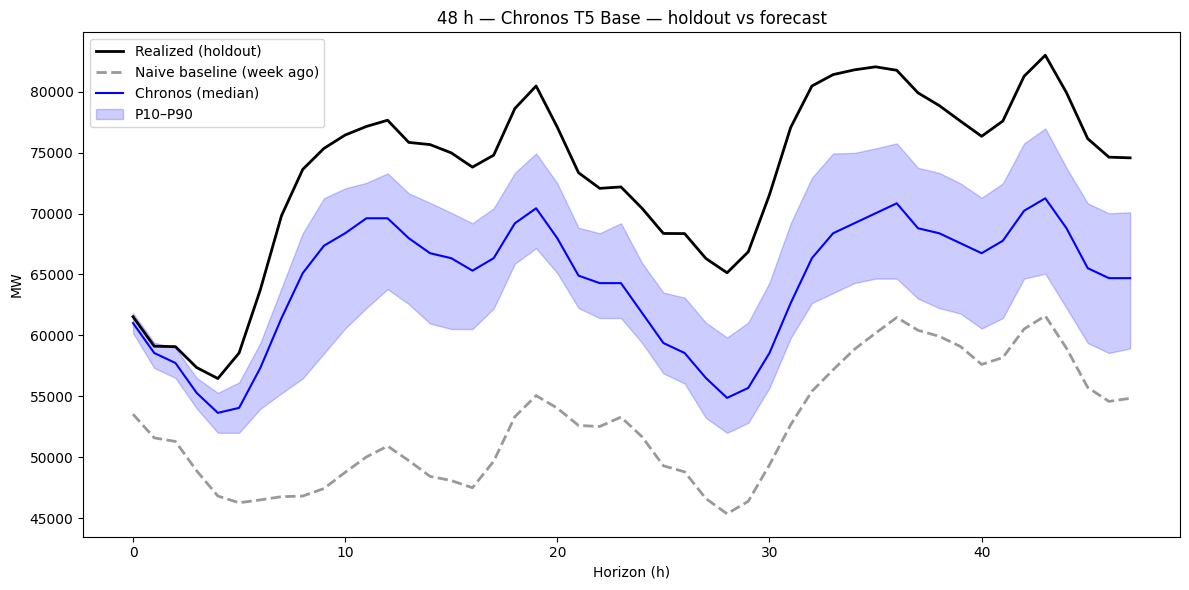

MAPE (Chronos median vs realized): 11.87%
MAPE (naive baseline vs realized): 27.88%
H+1: 0.85%
H+24: 10.94%
H+48: 13.24%


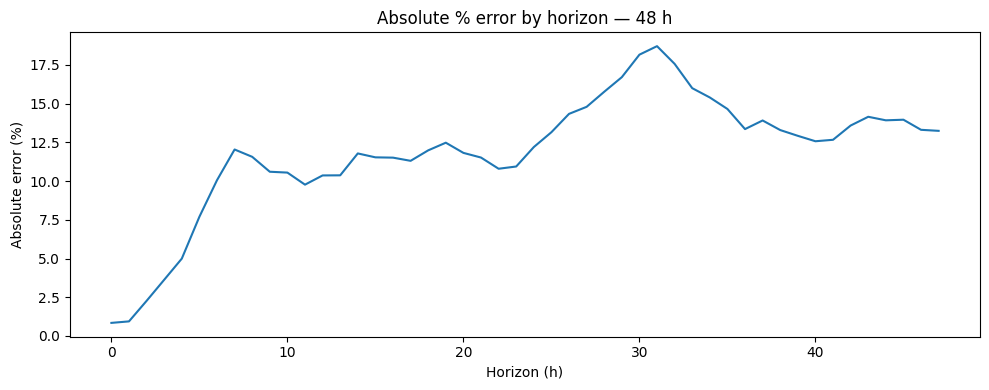

In [3]:
experiments = (
    {
        "label": "24 h — Chronos T5 Tiny",
        "window": EVAL_WINDOW_24H,
        "model_id": "amazon/chronos-t5-tiny",
    },
    {
        "label": "48 h — Chronos T5 Base",
        "window": EVAL_WINDOW_48H,
        "model_id": "amazon/chronos-t5-base",
    },
)

for exp in experiments:
    print(f"\n=== {exp['label']} ===")
    result = run_chronos_eval(
        y_series,
        exp["window"],
        model_id=exp["model_id"],
        device_map="cpu",
        num_samples=100,
    )
    for msg in result.sanity_messages:
        print(f"Note: {msg}")

    print(f"prediction_length={result.prediction_length}, window={result.window_name}")

    plot_forecast_comparison(
        result.ground_truth,
        result.baseline,
        result.median,
        result.low,
        result.high,
        prediction_length=result.prediction_length,
        title=f"{exp['label']} — holdout vs forecast",
    )

    m_model = mean_absolute_percentage_error(result.ground_truth, result.median)
    m_base = mean_absolute_percentage_error(result.ground_truth, result.baseline)
    print(f"MAPE (Chronos median vs realized): {m_model:.2f}%")
    print(f"MAPE (naive baseline vs realized): {m_base:.2f}%")

    err_pct = per_horizon_percentage_error(result.ground_truth, result.median)
    for h in (1, 24, 48):
        if h <= result.prediction_length:
            print(f"H+{h}: {err_pct[h - 1]:.2f}%")

    plot_horizon_errors(
        err_pct,
        prediction_length=result.prediction_length,
        title=f"Absolute % error by horizon — {result.prediction_length} h",
    )